# t-SNE on raw trajectories

In [1]:
import numpy as np
data = np.load("../../../simulated_data/001-gridrobot/data/gridrobot_1960.npz")
all_trajs = data["trajs"]
all_feats = data["features"]

------ Agent MDP ------
num X :  5
num Y :  5
obstacles :  0
-----------------------


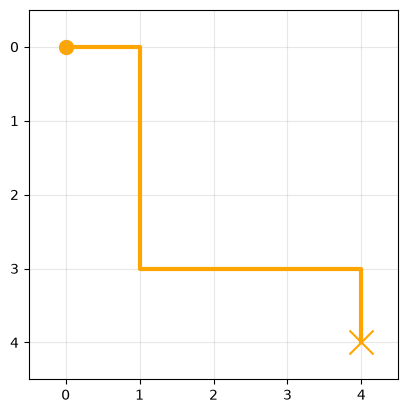

In [2]:
import sys
sys.path.insert(0, '../../../simulated_data/001-gridrobot/')
from gridrobot import Gridrobot
    
config = {
    "X": 5,
    "Y": 5,
    "obstacles": [],
    "starts": [[0, 0], [0, 4], [4, 0], [4, 4]],
    "goals": [[4, 4], [4, 0], [0, 4], [0, 0]],
    "features": ["computer_dist", "joint_up"],
    "thetas": [[ -10.0, -10.0 ],
              [ 0.0, -10.0 ],
              [ 10.0, -10.0 ],
              [ -10.0, 0.0 ],
              [ 10.0, 0.0 ],
              [ -10.0, 10.0 ],
              [ 0.0, 10.0 ],
              [ 10.0, 10.0 ]
    ],
    "beta": 10.0,
    "feature_scaling": "normalize",
    "train_test_split": 0.8
}
env = Gridrobot(config["X"], config["Y"], config["obstacles"], config["starts"], config["goals"])
env.visualize_one_traj(all_trajs[0])

In [3]:
import plotly.graph_objects as go
from ipywidgets import Output, HBox
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def fancy_scatter(data_2d, title, x_label=None, y_label=None, color_array=None):
    # # t-SNE (same as before) — order is preserved, so row i <-> all_trajs[i]
    # trajs_t_sne = TSNE(n_components=2, random_state=0).fit_transform(all_trajs)

    marker = dict(size=8, opacity=0.7)
    if color_array is not None:
        marker.update(
            color=color_array,
            colorscale="Viridis",
            cmin=0, cmax=1,                    # values are 0–1
            showscale=True,
            colorbar=dict(title="value"),
        )
    
    scatter = go.FigureWidget(
        data=[go.Scatter(
            x=data_2d[:, 0],
            y=data_2d[:, 1],
            mode="markers",
            marker=marker,
            customdata=list(range(len(data_2d))),
            hovertemplate="traj %{customdata}<extra></extra>",
        )]
    )
    
    scatter.update_layout(
        width=500, 
        height=500, 
        title=title)
    if x_label:
        scatter.update_layout(
            xaxis_title=x_label
            )
    if y_label:
        scatter.update_layout(
            yaxis_title=y_label
            )

    # side panel where the trajectory gets drawn
    out = Output()

    def show_traj(trace, points, state):
        if not points.point_inds:
            return
        idx = points.point_inds[0]
        with out:
            clear_output(wait=True)          # replace the previous trajectory
            env.visualize_one_traj(all_trajs[idx])
            plt.show()

    scatter.data[0].on_hover(show_traj)

    display(HBox([scatter, out]))  # scatter on the left, trajectory on the right

In [4]:
t_sne = TSNE(
    n_components=2,
    # perplexity=30,
    # init="random",
    # max_iter=250,
    random_state=0,
)
trajs_t_sne = t_sne.fit_transform(all_trajs)
fancy_scatter(trajs_t_sne, "raw traj t-SNE", color_array=all_feats[:,0]) # colored by laptop feature value

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

4 distinct clusters, 1 per (start point, end point) pair (since trajectory always goes from one corner to the opposite corner)

# 

## tversky sim output on raw trajs

In [81]:
import pandas as pd
results = "../results/ljts/results.csv"
res_df = pd.read_csv(results)

In [100]:
sys.path.insert(0, '../src')
from literally_just_tversky_sim import load_tversky_sim
import torch

for fbank_size in [2, 4, 8, 16, 32, 64, 128, 256]:
    ckpt = res_df[(res_df['seed'] == 0) & (res_df['fbank_size']==fbank_size)]['ckpt_path'].item()
    tversky_sim = load_tversky_sim(f"../{ckpt}")
    all_sim = tversky_sim.similarity(torch.tensor(all_trajs, dtype=torch.float32), torch.tensor(all_trajs, dtype=torch.float32))
    t_sne = TSNE(
        n_components=2,
        # perplexity=30,
        init="random",
        # # max_iter=250, # when this is commented back in, below t-SNE has all points very close to origin but several outliers
        random_state=0,
        metric="precomputed" # we pass in pairways similarity matrix
    )
    shifted_all_sim = all_sim + torch.abs(all_sim.min()).item() # in case of negative similarities, which t sne does not allow
    tversky_sim_raw_t_sne = t_sne.fit_transform(shifted_all_sim.detach().numpy())
    fancy_scatter(tversky_sim_raw_t_sne, f"tversky sim on raw trajs fbank {fbank_size}", color_array=all_feats[:,0])

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

# feature vectors

In [11]:
fancy_scatter(all_feats, "2D ground truth feature vectors", x_label="laptop", y_label="upright", color_array=all_feats[:,0])

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

## tversky sirl on ground truth feats

In [20]:
sys.path.insert(0, '../src')
from literally_just_tversky_sim import load_tversky_sim
import torch

# fbank size 64, seed 2, best performing according to query-ability
ckpt = "../results/ground_truth_feats_ljts/tversky_proj_1785776164.pth"
tversky_sim = load_tversky_sim(ckpt)
all_sim = tversky_sim.similarity(torch.tensor(all_feats, dtype=torch.float32), torch.tensor(all_feats, dtype=torch.float32))

In [21]:
all_sim

tensor([[  5.8541,  -0.4815,   4.1208,  ...,  -5.4509,  -3.3519,   5.8541],
        [ -1.6082,   1.2120,  -3.8407,  ...,  -2.6717,  -1.8850,  -1.6082],
        [  5.1574,  -1.6774,  11.1772,  ...,  -8.0077,  -5.9279,   5.1574],
        ...,
        [ -7.6608,  -3.7548, -11.2542,  ...,   0.0000,  -2.2877,  -7.6608],
        [ -4.9019,  -2.3083,  -8.5145,  ...,  -1.6278,   0.5634,  -4.9019],
        [  5.8541,  -0.4815,   4.1208,  ...,  -5.4509,  -3.3519,   5.8541]],
       grad_fn=<SubBackward0>)

In [32]:
# all_sim has negative elements, so let's add the minimum val to make them all positive for visualization (tSNE will error with negative similarities)
torch.min(all_sim).item()

-14.66958999633789

In [34]:
shifted_all_sim = all_sim + torch.abs(all_sim.min()).item()

In [35]:
shifted_all_sim.min()

tensor(0., grad_fn=<MinBackward1>)

In [38]:
t_sne = TSNE(
    n_components=2,
    # perplexity=30,
    init="random",
    # # max_iter=250, # when this is commented back in, below t-SNE has all points very close to origin but several outliers
    random_state=0,
    metric="precomputed" # we pass in pairways similarity matrix
)
tversky_sim_feats_t_sne = t_sne.fit_transform(shifted_all_sim.detach().numpy())
tversky_sim_feats_t_sne.shape
fancy_scatter(tversky_sim_feats_t_sne, "tversky sim on ground truth feats", color_array=all_feats[:,0])

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

actually seems like it's learning some things - most yellow (laptop 0) points are indeed close together, and darkest poitns (laptop 1) seem also close, even manages to somewhat cluster by uprightness (yellow curve in the middle is all far from laptop, perfectly upright) - but points with intermediate laptop distances are all over the place.

this isn't crazy since we only train the tversky sim layer on max and min laptop trajectories; maybe the main issue is making use of the full dataset (e.g. non-extremal)?

# sirl embeds

In [12]:
import torch
from sirl import load_sirl

def sirl(trajs, latent_dim):
    """
    take frozen SIRL encoder from expt 003
    load from sirl_ckpts (copied relevant ckpts into this dir)
    """
    ckpt_path = f"../sirl_ckpts/sirl_dim{latent_dim}_seed0.pth"
    print(f"loading ckpt {ckpt_path}")
    model = load_sirl(ckpt_path)
    model.eval()
    embeds = model(torch.tensor(trajs,dtype=torch.float32)).detach().numpy()
    return embeds

for latent_dim in [2, 4, 6, 8, 10]:
    sirl_embeds = sirl(all_trajs, latent_dim)
    if latent_dim > 2:
        t_sne = TSNE(
            n_components=2,
            # perplexity=30,
            # init="random",
            # max_iter=250,
            random_state=0,
        )
        sirl_embeds = t_sne.fit_transform(sirl_embeds)
    fancy_scatter(sirl_embeds, f"{latent_dim} dim SIRL embeds", color_array=all_feats[:,0])

loading ckpt ../sirl_ckpts/sirl_dim2_seed0.pth


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

loading ckpt ../sirl_ckpts/sirl_dim4_seed0.pth


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

loading ckpt ../sirl_ckpts/sirl_dim6_seed0.pth


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

loading ckpt ../sirl_ckpts/sirl_dim8_seed0.pth


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

loading ckpt ../sirl_ckpts/sirl_dim10_seed0.pth


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

## tversky sim on top of SIRL embeds

In [66]:
def sirl(trajs, latent_dim):
    """
    take frozen SIRL encoder from expt 003
    load from sirl_ckpts (copied relevant ckpts into this dir)
    """
    ckpt_path = f"../sirl_ckpts/sirl_dim{latent_dim}_seed0.pth"
    print(f"loading ckpt {ckpt_path}")
    model = load_sirl(ckpt_path)
    model.eval()
    embeds = model(torch.tensor(trajs,dtype=torch.float32)).detach()
    return embeds

In [78]:
sys.path.insert(0, '../src')
from literally_just_tversky_sim import load_tversky_sim
import torch

# latent dim 4, fbank size 16, seed 0
ckpt = "../results/sirl_ljts/tversky_proj_1785774111.pth"
tversky_sim = load_tversky_sim(ckpt)
embeds = sirl(torch.tensor(all_trajs, dtype=torch.float32), 4)
all_sim = tversky_sim.similarity(embeds, embeds)
t_sne = TSNE(
    n_components=2,
    # perplexity=30,
    init="random",
    # # max_iter=250, # when this is commented back in, below t-SNE has all points very close to origin but several outliers
    random_state=0,
    metric="precomputed" # we pass in pairways similarity matrix
)
sirl_tversky_sim_feats_t_sne = t_sne.fit_transform(all_sim.detach().numpy())
sirl_tversky_sim_feats_t_sne.shape
fancy_scatter(sirl_tversky_sim_feats_t_sne, "sirl (dim 4) -> tversky sim (fbank 16)", color_array=all_feats[:,0])

loading ckpt ../sirl_ckpts/sirl_dim4_seed0.pth


/var/folders/db/qlzd0qv57vd1ns6mt4y337d80000gn/T/ipykernel_64706/556169014.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeds = model(torch.tensor(trajs,dtype=torch.float32)).detach()


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

In [79]:
sys.path.insert(0, '../src')
from literally_just_tversky_sim import load_tversky_sim
import torch

# latent dim 4, fbank size 32, seed 0
ckpt = "../results/sirl_ljts/tversky_proj_1785774125.pth"
tversky_sim = load_tversky_sim(ckpt)
embeds = sirl(torch.tensor(all_trajs, dtype=torch.float32), 4)
all_sim = tversky_sim.similarity(embeds, embeds)
t_sne = TSNE(
    n_components=2,
    # perplexity=30,
    init="random",
    # # max_iter=250, # when this is commented back in, below t-SNE has all points very close to origin but several outliers
    random_state=0,
    metric="precomputed" # we pass in pairways similarity matrix
)
sirl_tversky_sim_feats_t_sne = t_sne.fit_transform(all_sim.detach().numpy())
sirl_tversky_sim_feats_t_sne.shape
fancy_scatter(sirl_tversky_sim_feats_t_sne, "sirl (dim 4) -> tversky sim (fbank 32)", color_array=all_feats[:,0])

loading ckpt ../sirl_ckpts/sirl_dim4_seed0.pth


/var/folders/db/qlzd0qv57vd1ns6mt4y337d80000gn/T/ipykernel_64706/556169014.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeds = model(torch.tensor(trajs,dtype=torch.float32)).detach()


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

In [75]:
# latent dim 6, fbank size 16, seed 0
ckpt = "../results/sirl_ljts/tversky_proj_1785774226.pth"
tversky_sim = load_tversky_sim(ckpt)
embeds = sirl(torch.tensor(all_trajs, dtype=torch.float32), 6)
all_sim = tversky_sim.similarity(embeds, embeds)
t_sne = TSNE(
    n_components=2,
    # perplexity=30,
    init="random",
    # # max_iter=250, # when this is commented back in, below t-SNE has all points very close to origin but several outliers
    random_state=0,
    metric="precomputed" # we pass in pairways similarity matrix
)
sirl_tversky_sim_feats_t_sne = t_sne.fit_transform(all_sim.detach().numpy())
sirl_tversky_sim_feats_t_sne.shape
fancy_scatter(sirl_tversky_sim_feats_t_sne, "sirl (dim 6) -> tversky sim on ground truth feats", color_array=all_feats[:,0])

loading ckpt ../sirl_ckpts/sirl_dim6_seed0.pth


/var/folders/db/qlzd0qv57vd1ns6mt4y337d80000gn/T/ipykernel_64706/556169014.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  embeds = model(torch.tensor(trajs,dtype=torch.float32)).detach()


    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

# pca

In [ ]:
from sklearn.decomposition import PCA

def pca(trajs, latent_dim):
    """
    pca to latent_dim
    """
    pca = PCA(n_components=latent_dim)
    embeds = pca.fit_transform(trajs) # (N, latent_dim)
    return embeds

for latent_dim in [2, 4, 6, 8, 10]:
    pca_embeds = pca(all_trajs, latent_dim)
    if latent_dim > 2:
        t_sne = TSNE(
            n_components=2,
            # perplexity=30,
            # init="random",
            # max_iter=250,
            random_state=0,
        )
        pca_embeds = t_sne.fit_transform(pca_embeds)
    fancy_scatter(pca_embeds, f"{latent_dim} dim PCA embeds", color_array=all_feats[:,0])

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

# from expt 003: tversky projection trained with triplet loss

In [42]:
sys.path.insert(0, '../../003-tversky-methods-all-eval/src')
from tversky_proj import load_tversky_proj
import torch

# fbank size 128, seed 2, best performing according to query-ability
ckpt = "../../003-tversky-methods-all-eval/results/tversky_proj_gridrobot/tversky_proj_1784129526.pth"
tversky_proj = load_tversky_proj(ckpt)

In [45]:
all_sim = tversky_proj.encoder[0].similarity(torch.tensor(all_trajs, dtype=torch.float32), torch.tensor(all_trajs, dtype=torch.float32))

In [47]:
all_sim.min()

tensor(388.2668, grad_fn=<MinBackward1>)

In [49]:
t_sne = TSNE(
    n_components=2,
    # perplexity=30,
    init="random",
    # # max_iter=250, # when this is commented back in, below t-SNE has all points very close to origin but several outliers
    random_state=0,
    metric="precomputed" # we pass in pairways similarity matrix
)
tversky_proj_t_sne = t_sne.fit_transform(all_sim.detach().numpy())
fancy_scatter(tversky_proj_t_sne, "tversky proj trained with triplet loss", color_array=all_feats[:,0])

    'data': [{'customdata': [0, 1, 2, ..., 1957, 1958, 1959],
              'hov…

In [53]:
tversky_proj.parameters()

<generator object Module.parameters at 0x319f926c0>

In [55]:
print(dict(tversky_sim.named_parameters()).keys())

dict_keys(['tversky_sim.theta', 'tversky_sim.alpha', 'tversky_sim.beta', 'tversky_sim.feature_bank.weight'])
